In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/minuteCaloriesNarrow_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/weightLogInfo_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/minuteMETsNarrow_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/hourlyCalories_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/heartrate_seconds_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/minuteSleep_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/hourlyIntensities_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitaba

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dailyActivity = pd.read_csv("/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv")
sleepDay = pd.read_csv("/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/sleepDay_merged.csv")


In [3]:
#process phase

#checking data integrity

#validate file import
print(dailyActivity.shape,"\n",
      sleepDay.shape)

#inspect colummns to ensure all expected columns exist
print(dailyActivity.columns,"\n",
      sleepDay.columns)

#count users
print(dailyActivity["Id"].nunique(),"\n",
     sleepDay["Id"].nunique())

#review data type
print(dailyActivity.info,"\n",
     sleepDay.info)

#detect duplicates
print(dailyActivity.duplicated().sum(),"\n",
     sleepDay.duplicated().sum())

#review missing values
print(dailyActivity.isnull().sum(),"\n",
      sleepDay.isnull().sum())

#check impossible values
print(dailyActivity[dailyActivity["TotalSteps"] < 0], "\n",
dailyActivity[dailyActivity["Calories"] < 0], "\n",
sleepDay[sleepDay["TotalMinutesAsleep"] < 0])


(940, 15) 
 (413, 5)
Index(['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance',
       'LoggedActivitiesDistance', 'VeryActiveDistance',
       'ModeratelyActiveDistance', 'LightActiveDistance',
       'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes',
       'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories'],
      dtype='object') 
 Index(['Id', 'SleepDay', 'TotalSleepRecords', 'TotalMinutesAsleep',
       'TotalTimeInBed'],
      dtype='object')
33 
 24
<bound method DataFrame.info of              Id ActivityDate  TotalSteps  TotalDistance  TrackerDistance  \
0    1503960366    4/12/2016       13162       8.500000         8.500000   
1    1503960366    4/13/2016       10735       6.970000         6.970000   
2    1503960366    4/14/2016       10460       6.740000         6.740000   
3    1503960366    4/15/2016        9762       6.280000         6.280000   
4    1503960366    4/16/2016       12669       8.160000         8.160000   
..     

In [4]:
#cleaning data

#convert date columns to date dtype
dailyActivity["ActivityDate"] = pd.to_datetime(dailyActivity["ActivityDate"])
sleepDay["SleepDay"] = pd.to_datetime(sleepDay["SleepDay"])

#remove duplicates
sleepDay = sleepDay.drop_duplicates()
print(sleepDay.duplicated().sum())

#verify numeric fields
print(dailyActivity.dtypes,"\n",
      sleepDay.dtypes)

#create day of week
dailyActivity["DayOfWeek"] = dailyActivity["ActivityDate"].dt.day_name()

#create consistent date key
sleepDay["Date"] = sleepDay["SleepDay"].dt.date
dailyActivity["Date"] = dailyActivity["ActivityDate"].dt.date
dailyActivity["Date"] = pd.to_datetime(dailyActivity["Date"])
sleepDay["Date"] = pd.to_datetime(sleepDay["Date"])

#merge datasets
dailySleep = pd.merge(dailyActivity, sleepDay, on=["Id","Date"], how="inner")

0
Id                                   int64
ActivityDate                datetime64[ns]
TotalSteps                           int64
TotalDistance                      float64
TrackerDistance                    float64
LoggedActivitiesDistance           float64
VeryActiveDistance                 float64
ModeratelyActiveDistance           float64
LightActiveDistance                float64
SedentaryActiveDistance            float64
VeryActiveMinutes                    int64
FairlyActiveMinutes                  int64
LightlyActiveMinutes                 int64
SedentaryMinutes                     int64
Calories                             int64
dtype: object 
 Id                             int64
SleepDay              datetime64[ns]
TotalSleepRecords              int64
TotalMinutesAsleep             int64
TotalTimeInBed                 int64
dtype: object


/tmp/ipykernel_16/4032238980.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sleepDay["SleepDay"] = pd.to_datetime(sleepDay["SleepDay"])


In [5]:
#verify data cleaning

#check no duplicates remain
print(dailySleep.duplicated().sum())

#check no missing values in critical fields
print(dailySleep[["Id", "Date", "TotalSteps", "TotalMinutesAsleep"]].isnull().sum())

#check correct data types
print(dailySleep.info())

#check reasonable ranges
print(dailySleep["TotalSteps"].describe())

#spot check visually
print(dailySleep.head())



0
Id                    0
Date                  0
TotalSteps            0
TotalMinutesAsleep    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Id                        410 non-null    int64         
 1   ActivityDate              410 non-null    datetime64[ns]
 2   TotalSteps                410 non-null    int64         
 3   TotalDistance             410 non-null    float64       
 4   TrackerDistance           410 non-null    float64       
 5   LoggedActivitiesDistance  410 non-null    float64       
 6   VeryActiveDistance        410 non-null    float64       
 7   ModeratelyActiveDistance  410 non-null    float64       
 8   LightActiveDistance       410 non-null    float64       
 9   SedentaryActiveDistance   410 non-null    float64       
 10  VeryActiveMinutes         410 non-n

33 
 24
7637.9106382978725
2303.609574468085
991.2106382978724
VeryActiveMinutes        21.164894
FairlyActiveMinutes      13.564894
LightlyActiveMinutes    192.812766
dtype: float64
419.17317073170733
458.4829268292683
0.5915680862453355
DayOfWeek
Friday       7448.230159
Monday       7780.866667
Saturday     8152.975806
Sunday       6933.231405
Thursday     7405.836735
Tuesday      8125.006579
Wednesday    7559.373333
Name: TotalSteps, dtype: float64
                   Count  Percentage
SleepCategory                       
7-9 hours            190       46.34
9+ hours              39        9.51
Less than 7 hours    181       44.15


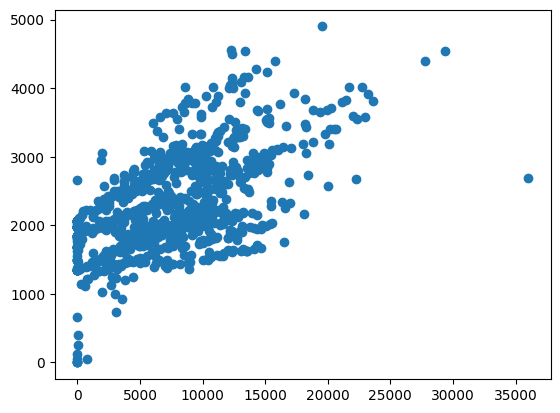

In [6]:
#analyze phase

#descriptive analysis

#get number of users. 
#finding: activity tracking appears more common than sleep tracking. this suggests sleep tracking may require more user education/engagement
print(dailyActivity["Id"].nunique(), "\n",
     sleepDay["Id"].nunique())

#get average daily steps
#finding: assuming the common benchmark is, the 10k steps, the user average is below that goal. Many users are active, but not optimally active. This creates an opportunity for step goals and reminders within the Bellabeat Leaf smart device.
print(dailyActivity["TotalSteps"].mean())

#get average calories burned
#finding: users burned a substantial number of calories on average each day. Bellabeat could personalize calorie summaries.
print(dailyActivity["Calories"].mean())

#get sedentary time
#finding: users were 991/60 = 16.5 hours/day sedentary. Users who own fitness tracks spend much of the day inactive. Bellabeat could promote movement and stretch reminders.
print(dailyActivity["SedentaryMinutes"].mean())

#get activity intensity
#finding: most activity is light activity. Marketing should emphasiz wellness through everyday movement, not become an elite athlete.
print(dailyActivity[["VeryActiveMinutes", "FairlyActiveMinutes", "LightlyActiveMinutes"]].mean())

#get average sleep
#finding: assuming most healthy adults should sleep between 7-9 hrs a day, most users were under that goal, being asleep 419.173 / 60 = 6.98 hrs/day. Leaf can promote sleep consistency and bedtime habits.
print(sleepDay["TotalMinutesAsleep"].mean())

#compare time in bed vs sleep
#finding: assuming the ideal duration to fall asleep is 10-20 minutes, users had trouble falling asleep. Users took 458.4829268292683 - 419.17317073170733 = 39.31 minutes on average to fall asleep. Bellabeat could provide sleep education content
print(sleepDay["TotalTimeInBed"].mean())

#get relationsihp between steps and calories
#finding: there is a moderate positive relationship between steps and calories
print(dailyActivity["TotalSteps"].corr(dailyActivity["Calories"]))
plt.scatter(dailyActivity["TotalSteps"], dailyActivity["Calories"])

#get activity by day of week
#finding: average steps for Sunday was low, and Tuesday and Saturday's was high. Bellabeat could promot Sunday reset challenges
weekdaySteps = (dailyActivity.groupby("DayOfWeek")["TotalSteps"].mean())
print(weekdaySteps)

#get sleep categories
#finding: most sleep observations fall in <7 hrs or 7-9 hrs. 
def sleep_category(minutes):
    if minutes < 420:
        return "Less than 7 hours"
    elif minutes <= 540:
        return "7-9 hours"
    else:
        return "9+ hours"

dailySleep["SleepCategory"] = dailySleep["TotalMinutesAsleep"].apply(sleep_category)
sleepCategoryCounts = dailySleep["SleepCategory"].value_counts()
sleepCategoryCounts = sleepCategoryCounts.reindex(["Less than 7 hours", "7-9 hours", "9+ hours"])
sleepCategoryPercentages = dailySleep["SleepCategory"].value_counts(normalize=True).mul(100).round(2)
sleepSummary = pd.DataFrame({"Count": sleepCategoryCounts, "Percentage":sleepCategoryPercentages})
print(sleepSummary)


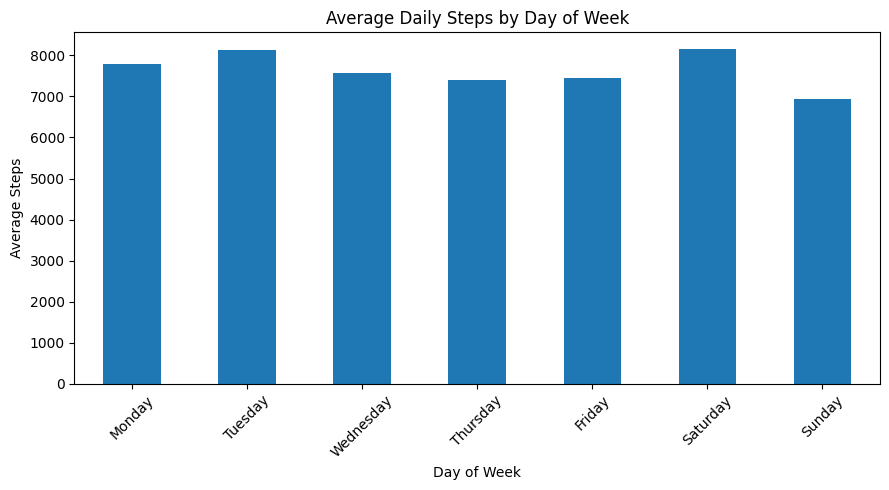

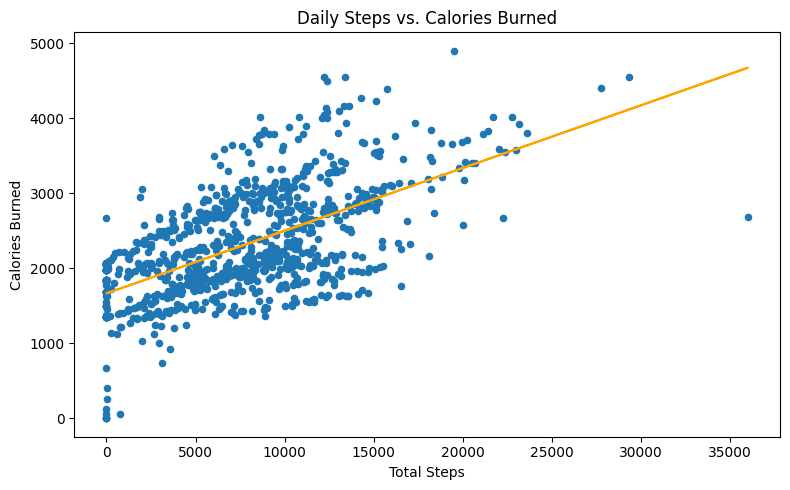

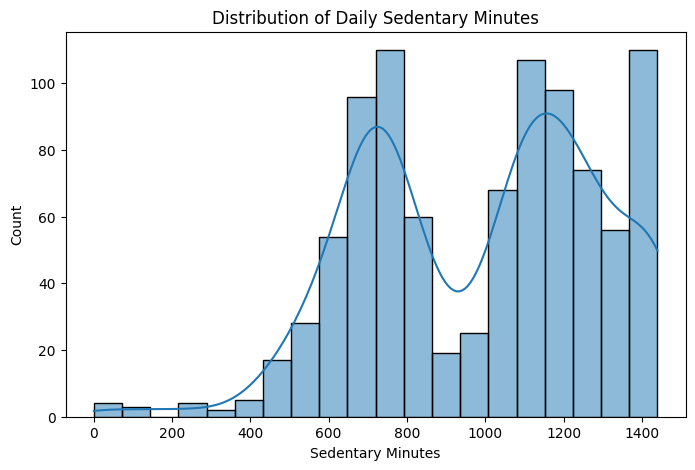

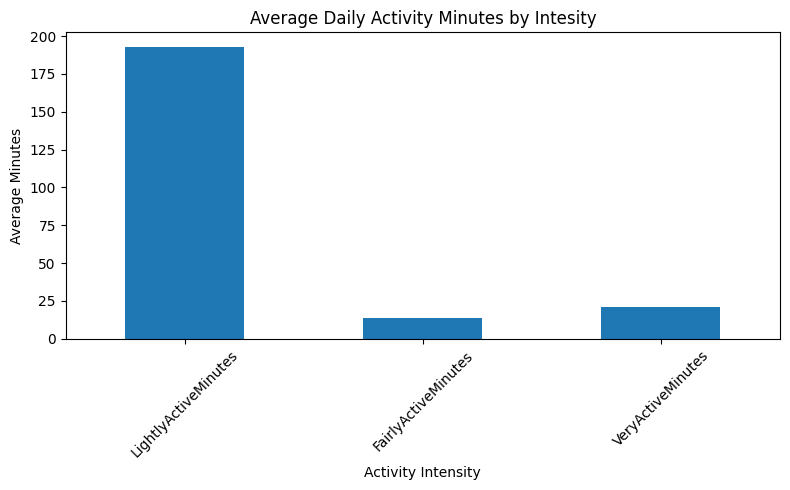

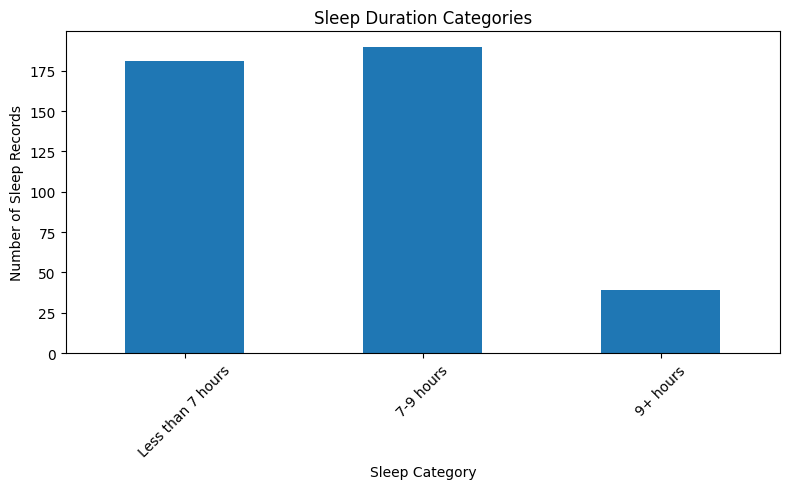

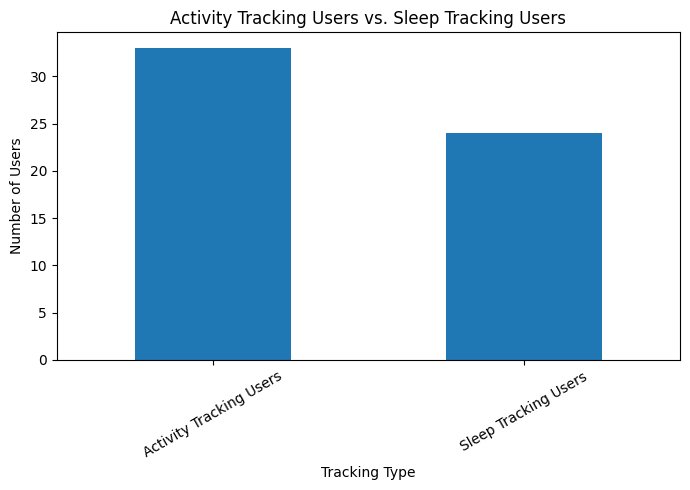

In [7]:
#share phase

#create viz of average daily steps by day of week
weekdaySteps = dailyActivity.groupby("DayOfWeek")["TotalSteps"].mean().reindex([
    "Monday", "Tuesday", "Wednesday","Thursday", "Friday", "Saturday", "Sunday"])
weekdaySteps.plot(kind="bar", figsize=(9,5))
plt.title("Average Daily Steps by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Steps")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#create viz for daily steps vs. calories burned
dailyActivity.plot(
    kind="scatter",
    x="TotalSteps",
    y="Calories",
    figsize=(8,5),
    title="Daily Steps vs. Calories Burned"
)
m, b = np.polyfit(dailyActivity["TotalSteps"], dailyActivity["Calories"], 1)
plt.plot(dailyActivity["TotalSteps"], m * dailyActivity["TotalSteps"] + b, color = "orange")
plt.xlabel("Total Steps")
plt.ylabel("Calories Burned")
plt.tight_layout()
plt.show()

#create viz of distribution of sedentary minutes
#finding: the distribution is right skewed and not normal. most observations occur at high sedentary-minute levels. this could be from random variation, or suggest two populations: active and sedentary users, or just be a threshold where relatively few people naturally fall.
plt.figure(figsize=(8,5))
sns.histplot(
    dailyActivity["SedentaryMinutes"],
    bins=20,
    kde=True
)
plt.title("Distribution of Daily Sedentary Minutes")
plt.xlabel("Sedentary Minutes")
plt.ylabel("Count")
plt.show()

#create viz for average activity minutes by intensity
activityIntensity = dailyActivity[["LightlyActiveMinutes", "FairlyActiveMinutes", "VeryActiveMinutes"]].mean()
activityIntensity.plot(kind="bar", figsize=(8,5))
plt.title("Average Daily Activity Minutes by Intesity")
plt.xlabel("Activity Intensity")
plt.ylabel("Average Minutes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#create viz for sleep duration categories
sleepCategoryCounts.plot(kind="bar", figsize=(8,5))
plt.title("Sleep Duration Categories")
plt.xlabel("Sleep Category")
plt.ylabel("Number of Sleep Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#create viz of activity users vs sleep users
trackingUsers = pd.Series({
    "Activity Tracking Users": dailyActivity["Id"].nunique(),
    "Sleep Tracking Users": sleepDay["Id"].nunique()
})

trackingUsers.plot(kind="bar",figsize=(7,5))
plt.title("Activity Tracking Users vs. Sleep Tracking Users")
plt.xlabel("Tracking Type")
plt.ylabel("Number of Users")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
